In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
results = pd.DataFrame([
    {'Model': 'mBERT',
     'f1_micro': 0.7182, 'f1_macro': 0.6345, 'f1_weighted': 0.7179,
     'precision_micro': 0.7374, 'recall_micro': 0.7000,
     'f1_toxic': 0.7416, 'f1_obscene': 0.7480, 'f1_insult': 0.7325,
     'f1_identity_hate': 0.6702, 'f1_threat': 0.4600, 'f1_severe_toxic': 0.4545,
     'roc_auc_toxic': 0.9064, 'roc_auc_obscene': 0.9884, 'roc_auc_insult': 0.9083,
     'roc_auc_identity_hate': 0.9084, 'roc_auc_threat': 0.9722, 'roc_auc_severe_toxic': 0.9926},
    {'Model': 'XLM-R',
     'f1_micro': 0.7270, 'f1_macro': 0.6525, 'f1_weighted': 0.7266,
     'precision_micro': 0.7513, 'recall_micro': 0.7042,
     'f1_toxic': 0.7525, 'f1_obscene': 0.7672, 'f1_insult': 0.7395,
     'f1_identity_hate': 0.6763, 'f1_threat': 0.4854, 'f1_severe_toxic': 0.4940,
     'roc_auc_toxic': 0.9139, 'roc_auc_obscene': 0.9887, 'roc_auc_insult': 0.9143,
     'roc_auc_identity_hate': 0.9151, 'roc_auc_threat': 0.9896, 'roc_auc_severe_toxic': 0.9944},
    {'Model': 'Qwen2.5',
     'f1_micro': 0.7362, 'f1_macro': 0.6064, 'f1_weighted': 0.7353,
     'precision_micro': 0.7353, 'recall_micro': 0.7371,
     'f1_toxic': 0.7593, 'f1_obscene': 0.7544, 'f1_insult': 0.7504,
     'f1_identity_hate': 0.6907, 'f1_threat': 0.3243, 'f1_severe_toxic': 0.3594,
     'roc_auc_toxic': 0.9140, 'roc_auc_obscene': 0.9900, 'roc_auc_insult': 0.9139,
     'roc_auc_identity_hate': 0.9156, 'roc_auc_threat': 0.9825, 'roc_auc_severe_toxic': 0.9944},
])

print(results.to_string(index=False))

  Model  f1_micro  f1_macro  f1_weighted  precision_micro  recall_micro  f1_toxic  f1_obscene  f1_insult  f1_identity_hate  f1_threat  f1_severe_toxic  roc_auc_toxic  roc_auc_obscene  roc_auc_insult  roc_auc_identity_hate  roc_auc_threat  roc_auc_severe_toxic
  mBERT    0.7182    0.6345       0.7179           0.7374        0.7000    0.7416      0.7480     0.7325            0.6702     0.4600           0.4545         0.9064           0.9884          0.9083                 0.9084          0.9722                0.9926
  XLM-R    0.7270    0.6525       0.7266           0.7513        0.7042    0.7525      0.7672     0.7395            0.6763     0.4854           0.4940         0.9139           0.9887          0.9143                 0.9151          0.9896                0.9944
Qwen2.5    0.7362    0.6064       0.7353           0.7353        0.7371    0.7593      0.7544     0.7504            0.6907     0.3243           0.3594         0.9140           0.9900          0.9139                 0.915

Overall F1 Comparison

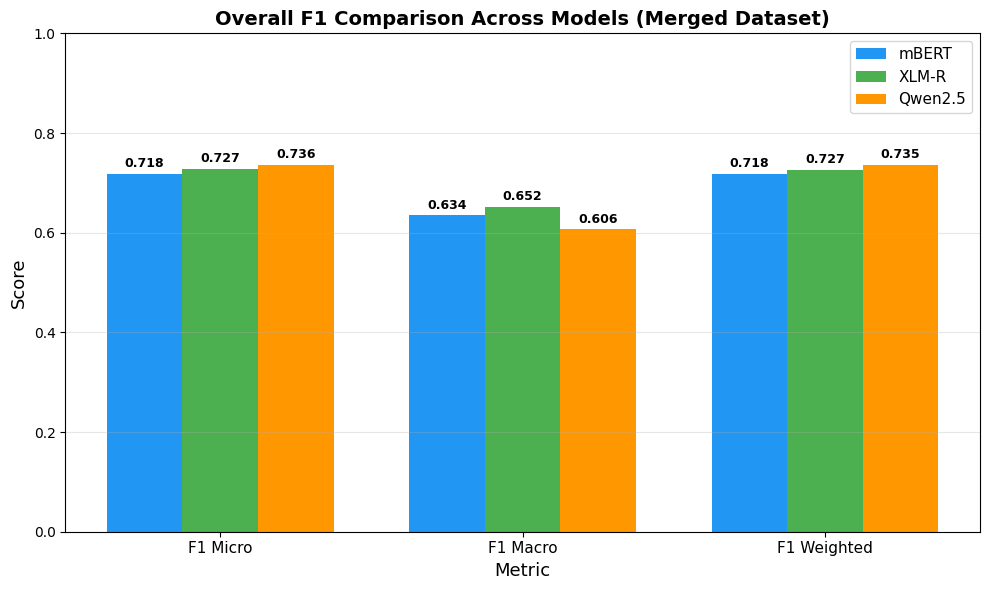

In [4]:
colors = {'mBERT': '#2196F3', 'XLM-R': '#4CAF50', 'Qwen2.5': '#FF9800'}
agg_metrics = ['f1_micro', 'f1_macro', 'f1_weighted']
models = results['Model'].tolist()

x = np.arange(len(agg_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    vals = [results[results['Model'] == model][m].values[0] for m in agg_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Overall F1 Comparison Across Models (Merged Dataset)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['F1 Micro', 'F1 Macro', 'F1 Weighted'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparison_overall_f1.png', dpi=300, bbox_inches='tight')
plt.show()

Per-Label F1 Comparison

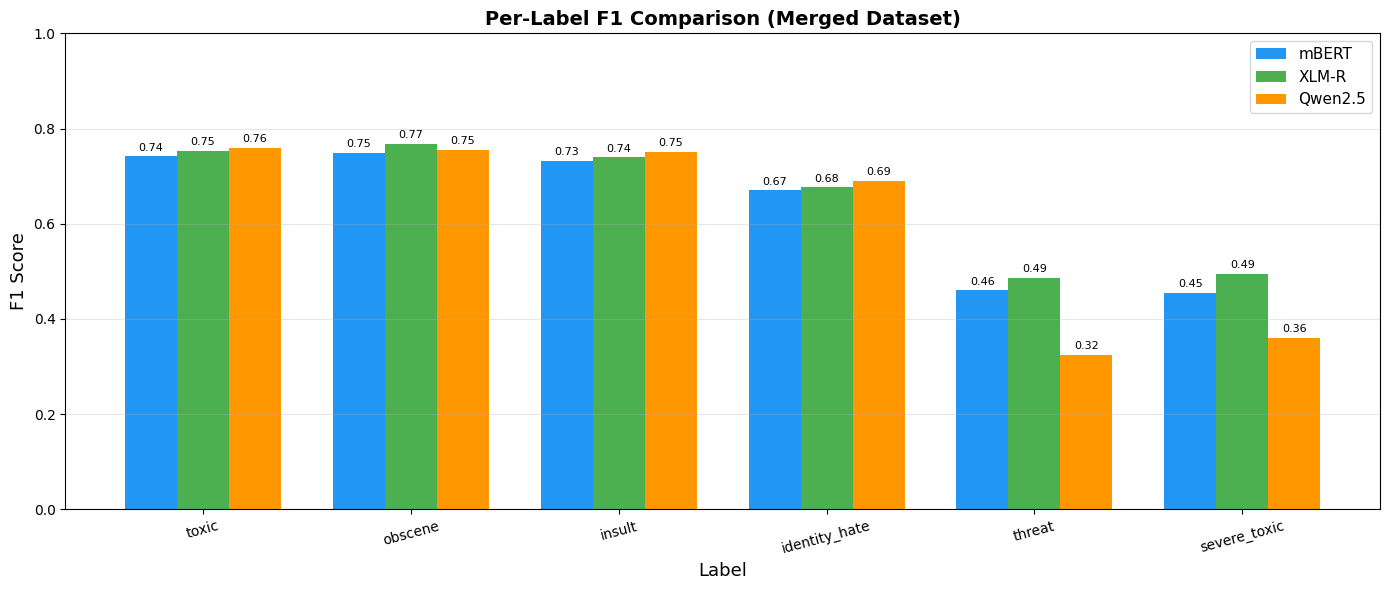

In [5]:
label_metrics = ['f1_toxic', 'f1_obscene', 'f1_insult', 'f1_identity_hate', 'f1_threat', 'f1_severe_toxic']
label_names = ['toxic', 'obscene', 'insult', 'identity_hate', 'threat', 'severe_toxic']

x = np.arange(len(label_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    vals = [results[results['Model'] == model][m].values[0] for m in label_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Label', fontsize=13)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('Per-Label F1 Comparison (Merged Dataset)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(label_names, rotation=15, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparison_per_label_f1.png', dpi=300, bbox_inches='tight')
plt.show()

Per-Label F1 Heatmap

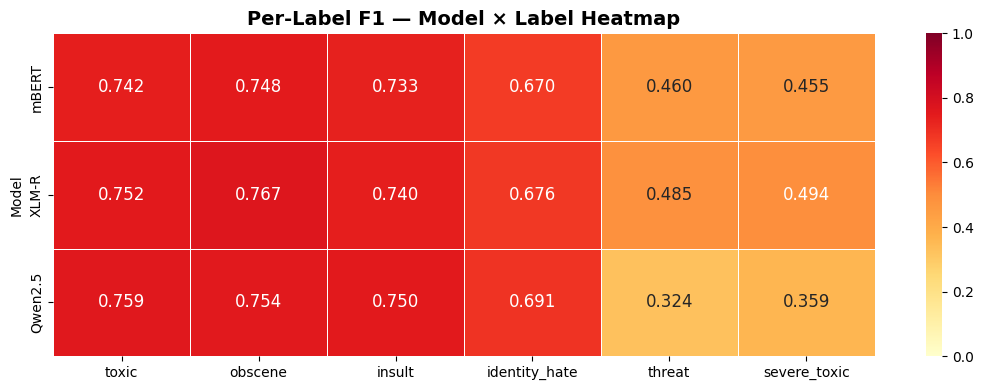

In [6]:
heatmap_df = results.set_index('Model')[label_metrics]
heatmap_df.columns = label_names

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            annot_kws={'size': 12}, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Per-Label F1 — Model × Label Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

ROC-AUC Comparison (often more flattering for imbalanced data)

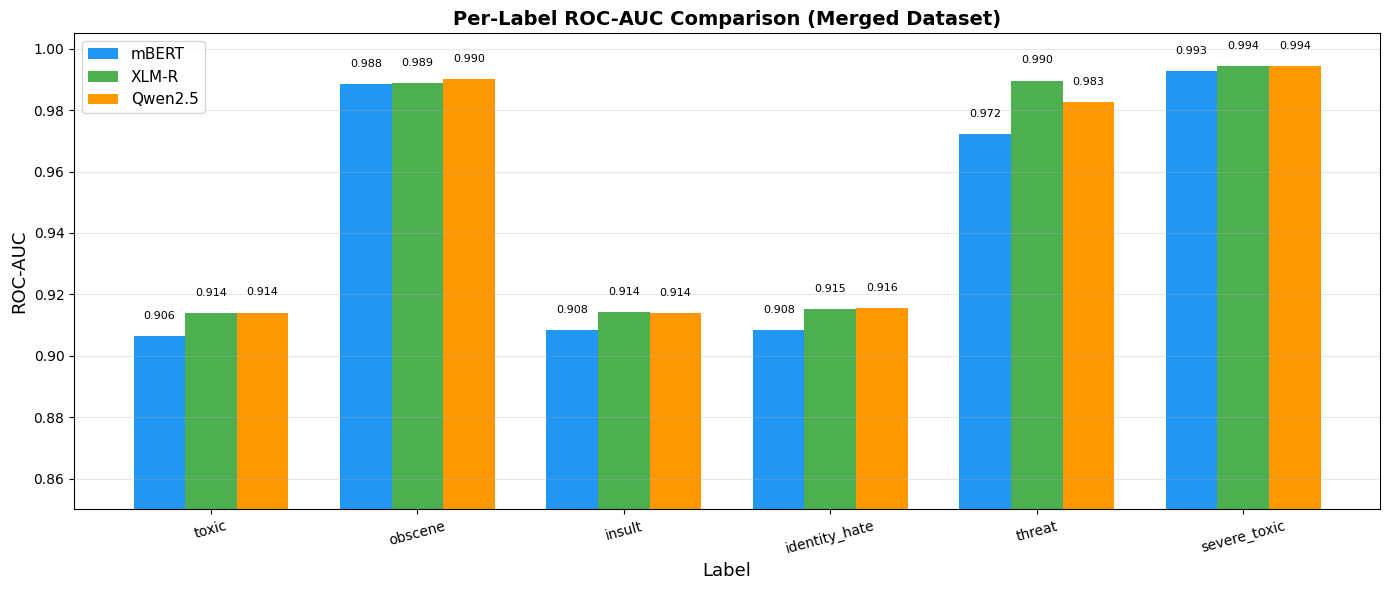

In [7]:
roc_metrics = ['roc_auc_toxic', 'roc_auc_obscene', 'roc_auc_insult',
               'roc_auc_identity_hate', 'roc_auc_threat', 'roc_auc_severe_toxic']

x = np.arange(len(label_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    vals = [results[results['Model'] == model][m].values[0] for m in roc_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Label', fontsize=13)
ax.set_ylabel('ROC-AUC', fontsize=13)
ax.set_title('Per-Label ROC-AUC Comparison (Merged Dataset)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(label_names, rotation=15, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0.85, 1.005)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparison_roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

Radar Chart

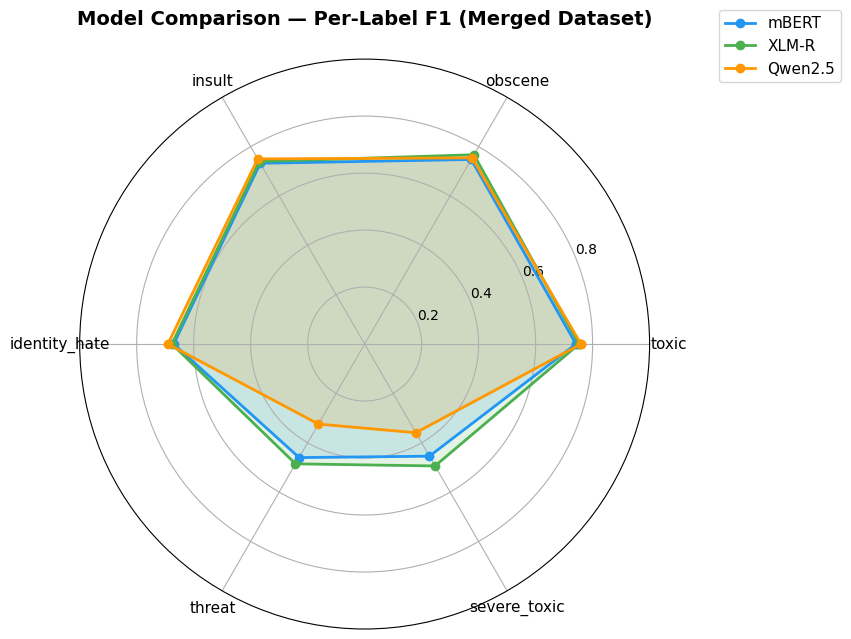

In [8]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(label_names), endpoint=False).tolist()
angles += angles[:1]

for _, row in results.iterrows():
    values = [row[m] for m in label_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[row['Model']])
    ax.fill(angles, values, alpha=0.15, color=colors[row['Model']])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_names, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_title('Model Comparison — Per-Label F1 (Merged Dataset)', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=300, bbox_inches='tight')
plt.show()

Summary Table

In [9]:
print("\n" + "=" * 100)
print("FULL RESULTS TABLE — ALL MODELS ON MERGED DATASET")
print("=" * 100)
print(results.to_string(index=False))

print("\n" + "=" * 100)
print("WINNERS PER METRIC")
print("=" * 100)

all_metric_cols = ['f1_micro', 'f1_macro', 'f1_weighted'] + label_metrics
for metric in all_metric_cols:
    winner = results.loc[results[metric].idxmax(), 'Model']
    val = results[metric].max()
    print(f"{metric:25s} → {winner:10s} ({val:.4f})")


FULL RESULTS TABLE — ALL MODELS ON MERGED DATASET
  Model  f1_micro  f1_macro  f1_weighted  precision_micro  recall_micro  f1_toxic  f1_obscene  f1_insult  f1_identity_hate  f1_threat  f1_severe_toxic  roc_auc_toxic  roc_auc_obscene  roc_auc_insult  roc_auc_identity_hate  roc_auc_threat  roc_auc_severe_toxic
  mBERT    0.7182    0.6345       0.7179           0.7374        0.7000    0.7416      0.7480     0.7325            0.6702     0.4600           0.4545         0.9064           0.9884          0.9083                 0.9084          0.9722                0.9926
  XLM-R    0.7270    0.6525       0.7266           0.7513        0.7042    0.7525      0.7672     0.7395            0.6763     0.4854           0.4940         0.9139           0.9887          0.9143                 0.9151          0.9896                0.9944
Qwen2.5    0.7362    0.6064       0.7353           0.7353        0.7371    0.7593      0.7544     0.7504            0.6907     0.3243           0.3594         0.9140    